Initial Data:
   severity  frequency  resolution_time  module  impact_score
0       NaN        3.0        11.233869     4.0      6.270161
1       2.0        2.0         0.504946     2.0      1.551484
2       4.0        6.0        10.784542     5.0      6.635363
3       2.0        2.0         1.601362     3.0      1.880408
4       4.0        NaN        16.241787     5.0      8.272536
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   severity         246 non-null    float64
 1   frequency        246 non-null    float64
 2   resolution_time  246 non-null    float64
 3   module           246 non-null    float64
 4   impact_score     246 non-null    float64
dtypes: float64(5)
memory usage: 10.2 KB
None


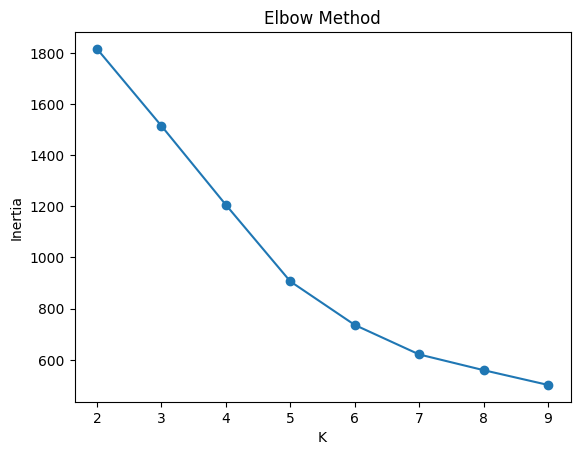

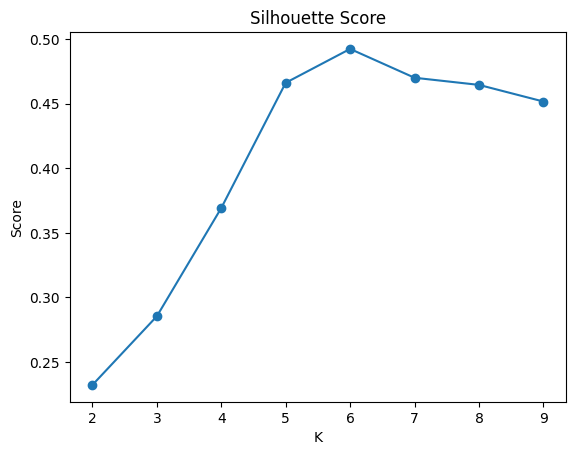

Optimal K: 6

Cluster Summary:
         severity  frequency  resolution_time    module  impact_score
Cluster                                                              
0        2.438356   5.946667         5.576843  3.000000      4.402654
1        3.625000  11.600000        15.495966  1.933333     15.622737
2        3.818182   6.375000        11.381930  5.000000      6.935374
3        3.340000   8.829787         9.230174  4.000000      6.565751
4        2.409091   6.744681         4.487619  2.000000      4.280164
5        1.533333   3.300000         2.809912  1.000000      2.479358

Module Distribution:
Cluster  module
0        3.0       68
1        1.0        7
         2.0        3
         3.0        4
         4.0        1
2        5.0       34
3        4.0       52
4        2.0       47
5        1.0       30
dtype: int64

Clustered Data Sample:
   severity  frequency  resolution_time  module  impact_score  Cluster
0       NaN        3.0        11.233869     4.0      6.270161    

In [5]:
# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 2. Load dataset
df = pd.read_csv(r'C:\Users\LENOVO\Jannavi\IITM GenAI\Scripts\it_tickets.csv')

print("Initial Data:")
print(df.head())
print(df.info())

# --------------------------------------------------
# 1. HANDLE MISSING VALUES
# --------------------------------------------------

# Separate columns by type
numeric_cols = ['severity', 'frequency', 'resolution_time', 'impact_score']
categorical_cols = ['module']

# Impute:
# - Numeric → mean
# - Categorical → most frequent

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# --------------------------------------------------
# 2. MODULE TREATMENT (Categorical vs Numeric)
# --------------------------------------------------
# ✔ Module is categorical → use OneHotEncoding (already done above)

# --------------------------------------------------
# 3. INCLUDE IMPACT SCORE?
# --------------------------------------------------
# ✔ We include it because:
# - It represents business importance
# - Helps clustering prioritize critical tickets

# (If needed, you can drop it like below)
# numeric_cols.remove('Impact_score')

# --------------------------------------------------
# 4. SCALING
# --------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

scaler = StandardScaler()

# --------------------------------------------------
# Combine preprocessing + scaling
# --------------------------------------------------

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', scaler)
])

X = pipeline.fit_transform(df)

# --------------------------------------------------
# 5 & 6. K-MEANS + OPTIMAL K
# --------------------------------------------------

inertia = []
silhouette = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, labels))

# Plot Elbow Method
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

# Plot Silhouette Score
plt.figure()
plt.plot(K_range, silhouette, marker='o')
plt.title('Silhouette Score')
plt.xlabel('K')
plt.ylabel('Score')
plt.show()

# Choose optimal K (example: best silhouette)
optimal_k = K_range[np.argmax(silhouette)]
print("Optimal K:", optimal_k)

# --------------------------------------------------
# 5. APPLY FINAL K-MEANS
# --------------------------------------------------

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

# --------------------------------------------------
# 7. INTERPRET CLUSTERS
# --------------------------------------------------

# Analyze clusters
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print("\nCluster Summary:")
print(cluster_summary)

# Count of modules per cluster
module_distribution = df.groupby(['Cluster', 'module']).size()
print("\nModule Distribution:")
print(module_distribution)

# View few rows
print("\nClustered Data Sample:")
print(df.head())

In [ ]:
🔴 Cluster 1 – Critical High-Impact Issues
Severity: High (3.62)
Frequency: Very high (11.6)
Resolution Time: Very high (15.49)
Impact Score: Very high (15.62)
Modules: Mixed (spread across multiple modules)

These are major incidents:

Occur frequently
Take long to resolve
Have high business impact
Action to be taken:
    
Immediate prioritization
Assign senior engineers
Root cause analysis needed

🟢 Cluster 5 – Low Priority Routine Tickets
Severity: Very low (1.53)
Frequency: Low (3.3)
Resolution Time: Very low (2.8)
Impact Score: Very low (2.47)
Module: Mostly Module 1

These are simple, routine issues:

Easy to fix
Low business impact
Action to be taken :
Automate handling
Assign to junior/support teams

🟡 Cluster 0 – Moderate Issues (Module-Specific)
Severity: Medium (2.43)
Frequency: Moderate (5.94)
Resolution Time: Moderate (5.57)
Impact: Moderate (4.40)
Module: Mostly Module 3 (68 tickets)

Recurring issues in a specific module
Not critical but frequent enough to matter

Action to be taken:
    
Investigate Module 3
Possible design/code improvements

🔵 Cluster 2 – Complex Module-Specific Issues
Severity: High (3.81)
Frequency: Moderate (6.37)
Resolution Time: High (11.38)
Impact: Medium (6.93)
Module: Entirely Module 5

Issues concentrated in Module 5
Hard to resolve → technical complexity
Action to be taken:
    
Deep technical audit
Refactor or redesign Module 5

🟣 Cluster 3 – Balanced Operational Issues
Severity: Medium-high (3.34)
Frequency: Moderate-high (8.83)
Resolution Time: Moderate (9.23)
Impact: Medium (6.56)
Module: Module 4 dominant

Regular operational problems
Affect productivity but not critical

Action to be taken:
    
Process improvements
Monitoring & preventive fixes

🟠 Cluster 4 – Low Severity but Frequent Issues
Severity: Medium-low (2.40)
Frequency: Moderate (6.74)
Resolution Time: Low (4.48)
Impact: Low (4.28)
Module: Module 2 dominant

Frequent but easy-to-fix issues
Likely usability or minor bugs
Action to be taken:
    
Bulk fixes
UI/UX improvements
Automation possible

📈 Overall Insights
🔍 1. Module-wise concentration
Module 5 → complex issues
Module 3 → recurring moderate issues
Module 1 → simple tickets
🔍 2. High-risk cluster identified
Cluster 1 = biggest concern
High severity + high impact + high resolution time
🔍 3. Optimization opportunities
Automate Cluster 5
Fix root causes in Cluster 0 & 4
Deep dive into Cluster 2
🎯 Final Report Conclusion

The clustering approach successfully segmented IT tickets into:

Critical incidents (Cluster 1)
Routine low-priority tickets (Cluster 5)
Module-specific recurring issues (Clusters 0, 2, 3, 4)

This enables:

Better prioritization
Improved resource allocation
Faster issue resolution
Targeted system improvements

In [ ]:
•	Which issues should be automated vs escalated? 
Automation vs Escalation Strategy
🤖 Issues to Automate
🟢 Cluster 5 – Routine Low-Priority Tickets
Low severity, low impact, quick resolution
Repetitive and predictable

👉 Examples:

Password resets
Minor configuration issues
Access requests
🟠 Cluster 4 – Frequent but Simple Issues
Moderate frequency but low complexity
Short resolution time

👉 Examples:

UI glitches
Minor bugs
Repetitive user errors
🟡 Cluster 0 – Moderate, Repetitive Module Issues (Module 3)
Not critical but occurs often

👉 Automation approach:

Predefined scripts
Self-service portals
Knowledge base solutions
🚨 Issues to Escalate
🔴 Cluster 1 – Critical High-Impact Incidents
High severity + high impact + long resolution time

👉 Must be escalated to:

Senior engineers
Incident response teams

👉 Examples:

System outages
Production failures
Security incidents
🔵 Cluster 2 – Complex Technical Issues (Module 5)
High severity + long resolution time
Technically challenging

👉 Escalate to:

Specialized teams
Product/engineering experts

👉 Focus:

Root cause analysis
Code/system redesign
🟣 Cluster 3 – Operationally Impactful Issues
Moderate-high severity and frequency

👉 Escalate when:

SLA breaches
Repeated failures

👉 Otherwise:

Handle with structured workflows
📊 Summary Table
Cluster	         Action	                      Reason
5	             Automate	               Low effort, repetitive
4	             Automate	                Frequent, simple fixes
0	             Automate (partially)	    Repetitive module issues
1	             Escalate	                Critical, high impact
2	             Escalate	                Complex, needs expertise
3	             Hybrid	                   Depends on severity/SLA

In [ ]:
•	Are there modules with frequent recurring problems? 
Modules with Frequent Recurring Issues
🔴 Module 3 → High Recurrence (Cluster 0)
Count: 68 tickets
Cluster type: Moderate severity, moderate frequency
Pattern: Same module repeatedly appearing

Strong indication of recurring issues in Module 3
Likely due to:
Design flaws
Poor error handling
Repeated user interactions triggering bugs
Action:
Prioritize root cause analysis
Consider code refactoring or redesign

🟠 Module 2 → Frequent Low-Complexity Issues (Cluster 4)
Count: 47 tickets
Pattern: Frequent but low severity and quick resolution

Not critical, but high volume of small issues
Often linked to:
Usability problems
Minor bugs
Action:
Fix in bulk releases
Improve UI/UX or validations

🟣 Module 4 → Operationally Frequent Issues (Cluster 3)
Count: 52 tickets
Pattern: Moderate-high frequency

Regular operational problems
Affect productivity over time
 Action:
Improve monitoring and preventive fixes

🔵 Module 5 → Recurring Complex Issues (Cluster 2)
Count: 34 tickets
Pattern: High severity + long resolution time

Fewer tickets than Module 3, but:
More complex
Harder to fix
 Action:
Deep technical review
Possibly architecture-level fixes

🟢 Module 1 → Low Recurrence (Cluster 5)
Count: 30 tickets
Pattern: Low frequency, low severity
=
Stable module
Mostly routine issues
Yes, modules with recurring problems exist, especially:

🚨 Most problematic:
Module 3 → highest recurrence
Module 2 & 4 → frequent operational issues
Module 5 → fewer but complex recurring issues

In [ ]:
•	Does impact_score dominate clustering?

Cluster 1 → very high impact_score
Cluster 5 → very low impact_score

So:
Impact score is helping differentiate clusters, but not overpowering them.